In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [53]:
df=pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")
df


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [54]:
df.shape 

(10000, 14)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [56]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [59]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [60]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [61]:
df.drop(columns=['Surname',"CustomerId","RowNumber"],inplace=True)

In [62]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [63]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [64]:

X=df.drop(columns=["Exited"])
y=df["Exited"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)


In [66]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [67]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [134]:
model=Sequential()
model.add(Dense(11,activation="sigmoid",input_dim=11))
model.add(Dense(11,activation="sigmoid"))

model.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [135]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
from tensorflow.keras.optimizers import Adam
model.compile(loss="binary_crossentropy",metrics=["accuracy"],optimizer=Adam(learning_rate=0.0001))

In [137]:
history=model.fit(X_train,y_train,epochs=100,batch_size=50 ,validation_split=0.2,verbose=1)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1994 - loss: 1.0128 - val_accuracy: 0.2025 - val_loss: 0.9524
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2003 - loss: 0.9368 - val_accuracy: 0.2025 - val_loss: 0.8851
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2043 - loss: 0.8692 - val_accuracy: 0.2025 - val_loss: 0.8260
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2060 - loss: 0.8111 - val_accuracy: 0.2025 - val_loss: 0.7754
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1989 - loss: 0.7643 - val_accuracy: 0.2025 - val_loss: 0.7321
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2311 - loss: 0.7225 - val_accuracy: 0.5081 - val_loss: 0.6951
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5818 - loss: 0.6871 - val_accuracy: 0.7731 - val_loss: 0.6639
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7757 - loss: 0.6566 - val_accu

In [138]:
model.layers[0].get_weights()

[array([[ 0.34316853, -0.38613528, -0.50215316, -0.20687701, -0.03108704,
          0.47411016,  0.10004131, -0.4003432 ,  0.17933244, -0.11598161,
         -0.2590527 ],
        [-0.38255128,  0.02615094,  0.19181566, -0.25754276,  0.07478374,
         -0.4098503 , -0.5013635 , -0.2445508 ,  0.34493655, -0.28913882,
          0.28086677],
        [-0.19532515,  0.1628772 ,  0.09082241, -0.03375759,  0.42866093,
          0.39194918, -0.38413575, -0.2610896 , -0.3873816 ,  0.27428055,
         -0.42667016],
        [ 0.26126766,  0.34109986,  0.01466667,  0.39019877,  0.01873654,
         -0.24714068,  0.26904735,  0.38474074,  0.1049927 ,  0.4463387 ,
         -0.41254434],
        [ 0.51987576,  0.14581198,  0.46060383,  0.43435818, -0.24533868,
         -0.39503708,  0.21076858, -0.23810923,  0.15881874,  0.11022228,
          0.34923255],
        [-0.31656384,  0.00351554, -0.31981212,  0.33717367,  0.1438787 ,
          0.29856637,  0.36803123, -0.40667868, -0.08222549, -0.4198452

In [139]:
model.layers[1].get_weights()

[array([[ 0.04488316, -0.07212805, -0.48100382,  0.19349304,  0.490262  ,
         -0.38719165, -0.23779827, -0.45621994, -0.35154635, -0.24706195,
          0.13648078],
        [-0.3164191 ,  0.46312135,  0.13075456, -0.24033591,  0.02968439,
         -0.25202185,  0.02864221, -0.44159245, -0.23577636, -0.14310677,
         -0.44668674],
        [-0.33003327,  0.2874427 , -0.33728582, -0.22798876, -0.19893992,
          0.02671511, -0.4233537 ,  0.25917503,  0.20713213, -0.2203979 ,
          0.11346383],
        [-0.65845877, -0.2590131 ,  0.7161858 , -0.14457314,  0.42100263,
          0.29309213, -0.08627482, -0.23581539, -0.12442388, -0.13325144,
          0.4026019 ],
        [ 0.3056123 , -0.28974503, -0.07812237, -0.06401061, -0.17977147,
          0.35062286, -0.05486826,  0.21323252,  0.15168756, -0.3063227 ,
          0.1793287 ],
        [-0.13424072,  0.23517719, -0.23215503, -0.49130973,  0.07797972,
         -0.33978713, -0.07444213, -0.49442917, -0.17133398, -0.1151133

In [140]:
model.layers[2].get_weights()

[array([[ 0.49836618],
        [ 0.3709296 ],
        [-0.6479763 ],
        [ 0.37971154],
        [-0.61522603],
        [ 0.26863176],
        [ 0.29351977],
        [ 0.03028373],
        [ 0.33381924],
        [-0.8368464 ],
        [-0.79495007]], dtype=float32),
 array([-0.22047535], dtype=float32)]

In [141]:
y_log=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [142]:
y_pred = y_pred.argmax(axis=-1)

In [143]:
y_pred=np.where(y_log>0.5,1,0)

In [144]:
from sklearn.metrics import accuracy_score
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.7925


In [145]:
history.history

{'accuracy': [0.20281249284744263,
  0.20281249284744263,
  0.20281249284744263,
  0.20281249284744263,
  0.20281249284744263,
  0.29593750834465027,
  0.6801562309265137,
  0.7796875238418579,
  0.7923437356948853,
  0.7951562404632568,
  0.7970312237739563,
  0.7970312237739563,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071

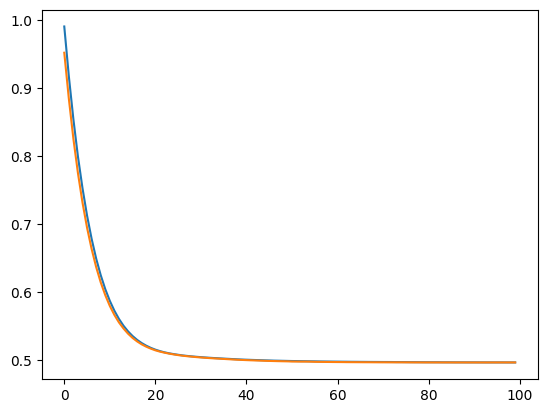

In [146]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

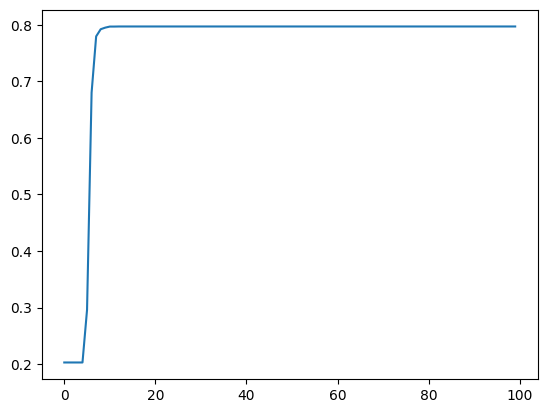

In [147]:
plt.plot(history.history["accuracy"])

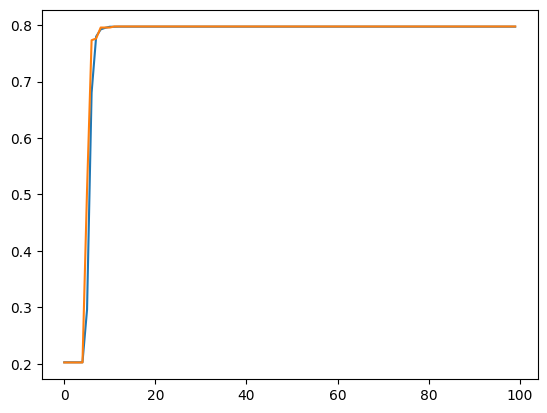

In [148]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])